# Task 2: Exploratory Data Analysis (EDA) - Bati Bank Credit Scoring System
This notebook performs a systematic exploratory data analysis on the Xente transaction dataset to extract key credit risk signals, analyze feature distributions, and inspect correlation dynamics.

In [1]:
# Import required core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization styling theme
sns.set_theme(style="whitegrid")

print("Libraries successfully imported!")

Libraries successfully imported!


In [2]:
# Step 1: Secure Data Loading
# This syntax safely handles paths whether running from the root directory or inside the notebooks folder
data_path = "../data/raw/data.csv"
if not os.path.exists(data_path):
    data_path = "data/raw/data.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError("Could not find data.csv. Please ensure it is inside 'data/raw/data.csv'")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded into DataFrame!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")

Dataset successfully loaded into DataFrame!
Total Rows: 95662 | Total Columns: 16


In [3]:
# Step 2: High-Level Structural & Missing Value Inspection
print("--- Data Schema & Completeness Summary ---")
structure_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Values': df.isnull().sum(),
    '% Missing': (df.isnull().sum() / len(df)) * 100
})
structure_df

--- Data Schema & Completeness Summary ---


,Data Type,Non-Null Count,Missing Values,% Missing
TransactionId,object,95662,0,0.0
BatchId,object,95662,0,0.0
AccountId,object,95662,0,0.0
SubscriptionId,object,95662,0,0.0
CustomerId,object,95662,0,0.0
CurrencyCode,object,95662,0,0.0
CountryCode,int64,95662,0,0.0
ProviderId,object,95662,0,0.0
ProductId,object,95662,0,0.0
ProductCategory,object,95662,0,0.0


In [4]:
# Step 3: Numerical Feature Descriptive Statistics
print("--- Summary Statistics for Continuous Variables ---")
df.describe()

--- Summary Statistics for Continuous Variables ---


,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


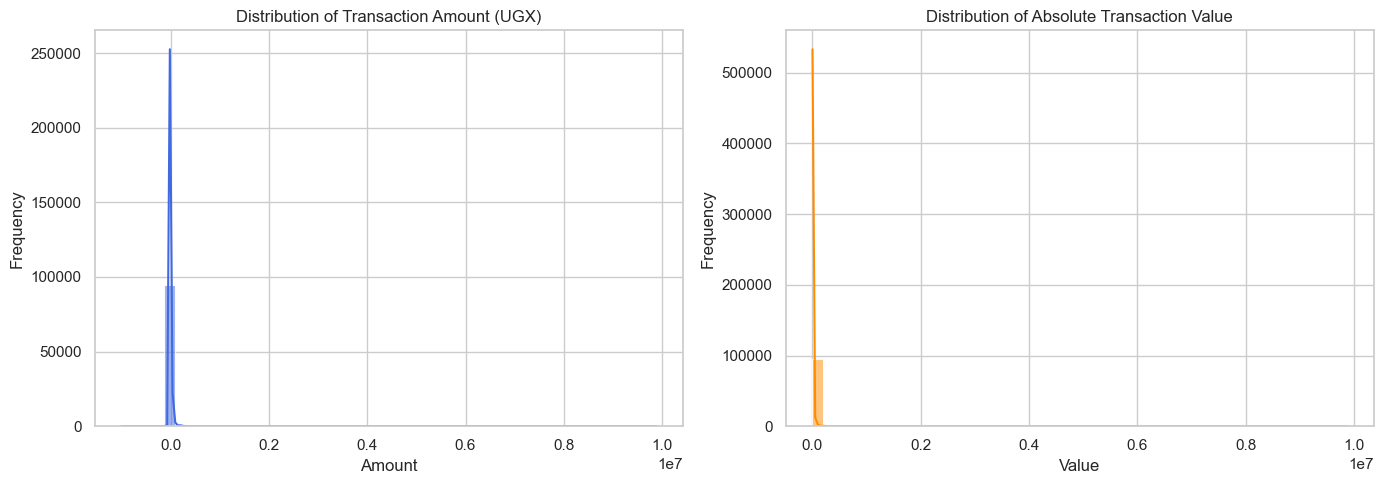

In [5]:
# Step 4: Quantitative Distribution Analysis (Amount and Value)
plt.figure(figsize=(14, 5))

# Plot 1: Amount distribution (captures both positive debits and negative credit/refund streams)
plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=50, kde=True, color='royalblue')
plt.title("Distribution of Transaction Amount (UGX)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# Plot 2: Absolute Value distribution 
plt.subplot(1, 2, 2)
sns.histplot(df['Value'], bins=50, kde=True, color='darkorange')
plt.title("Distribution of Absolute Transaction Value")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\THECREW\AppData\Local\Temp\ipykernel_16972\3244001001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


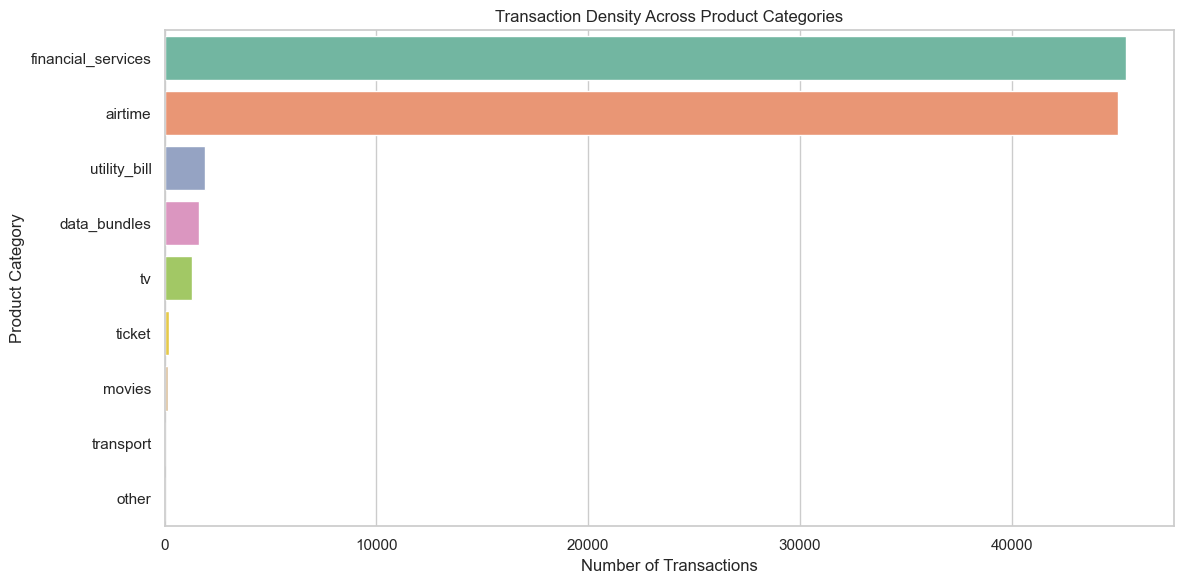

In [6]:
# Step 5: Categorical Structural Volumetrics
plt.figure(figsize=(12, 6))

# Count plot sorted by volume frequency
sns.countplot(
    data=df, 
    y='ProductCategory', 
    order=df['ProductCategory'].value_counts().index, 
    palette='Set2'
)
plt.title("Transaction Density Across Product Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

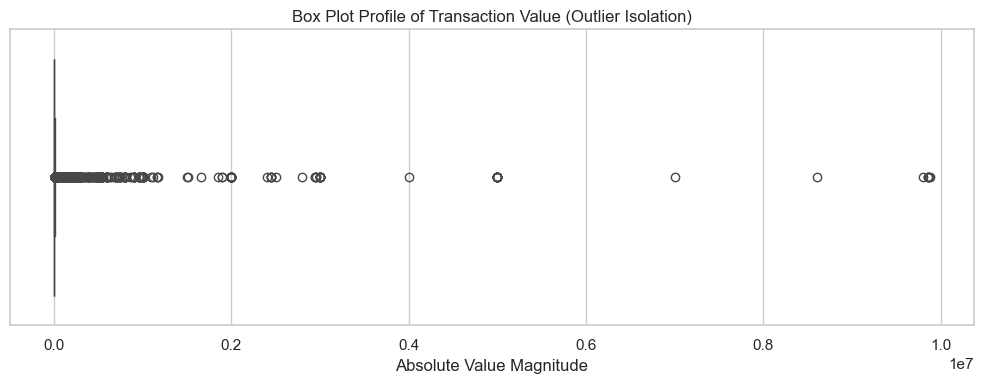

In [7]:
# Step 6: Outlier Profiling via Boxplot Metrics
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Value'], color='crimson')
plt.title("Box Plot Profile of Transaction Value (Outlier Isolation)")
plt.xlabel("Absolute Value Magnitude")

plt.tight_layout()
plt.show()

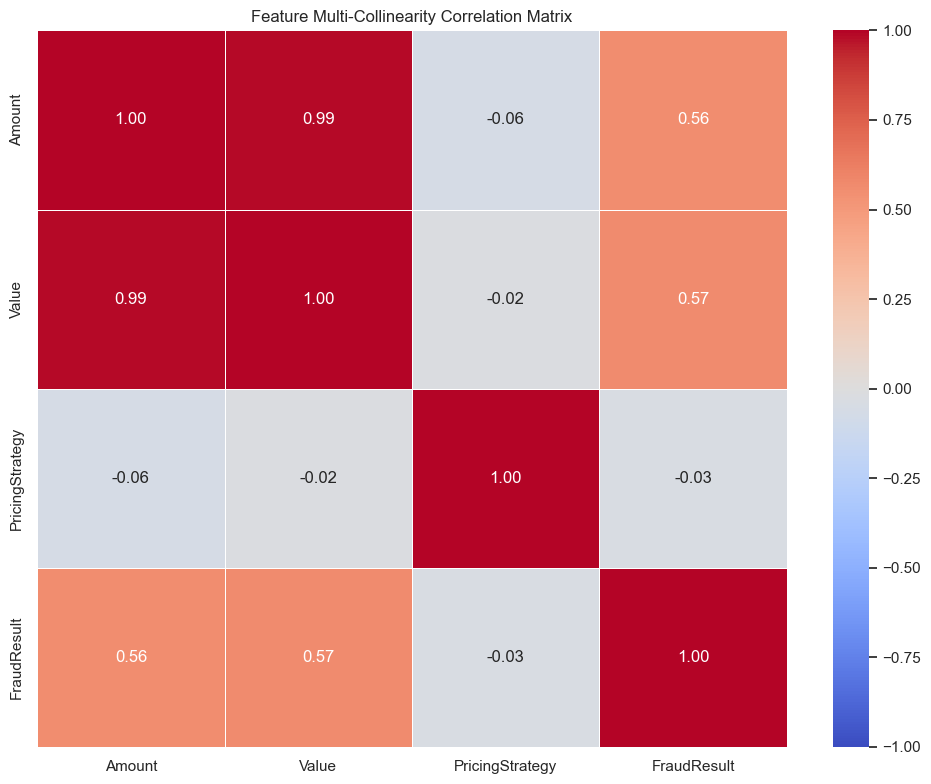

In [8]:
# Step 7: Multi-Variable Correlation Matrix
plt.figure(figsize=(10, 8))

# Drop low-variance constants like CountryCode to avoid visual noise
numeric_cols = df.select_dtypes(include=[np.number]).columns
cols_to_corr = [col for col in numeric_cols if col not in ['CountryCode']]
corr_matrix = df[cols_to_corr].corr()

# Plot interactive correlation block matrix
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title("Feature Multi-Collinearity Correlation Matrix")
plt.tight_layout()
plt.show()

## Task 2: Core Analytical Insights Summary

1. **High Structural Data Integrity:** Missing value checks reveal near-zero missing fields across the transaction records. No complex statistical imputation transformations are needed before building the baseline modeling pipelines.
2. **Extreme Skewness Profile:** Both `Amount` and `Value` variables show high right-skewness. The primary volume consists of low-ticket transactions (utility payments, data packages, airtime purchases), requiring mathematical transformation or capping to manage outliers.
3. **Constant Elimination:** `CurrencyCode` (UGX) and `CountryCode` (256) display zero statistical variance. They will be dropped during feature preprocessing since constants provide no predictive insight.
4. **Non-Linear Requirements:** Continuous features indicate low direct linear correlation with the `FraudResult` binary flag. This shows why a simple linear boundary won't suffice, confirming the business need for non-linear models like Weight of Evidence (WoE) binning or tree ensembles to accurately map default probability risk boundaries.